# Reservoir computing clásico y cuántico en señal compleja.

## Carga de librerías.

In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt
from sklearn.mixture import GaussianMixture
import random

## Generación de la señal compleja.

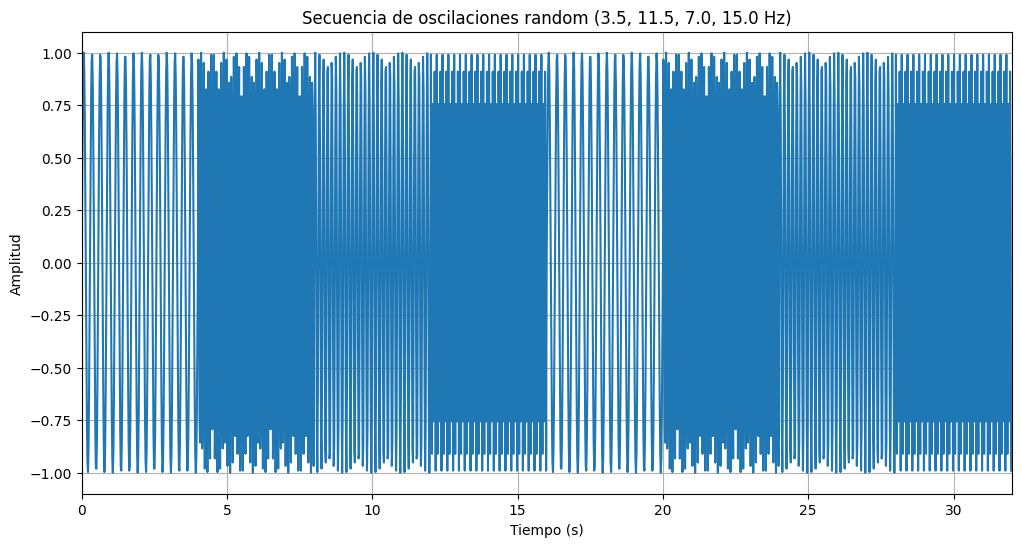

In [2]:
# Parámetros  
fs = 55            # Frecuencia de muestreo en Hz  
t_total = 32        # Duración total en segundos  
frecuencias = [3.5, 11.5, 7.0, 15.0]  # Cuatro frecuencias en Hz  
duracion_segmento = 4  # Duración de cada segmento en segundos  
num_repeticiones = 2 # 3 repeticiones = 12 segundos 

# Inicializamos la secuencia final como una lista  
secuencia2 = []  
amplitud = 1  

# Bucle externo para repetir el ciclo completo  
for i in range(num_repeticiones):  
    # Bucle interno para iterar sobre cada frecuencia en el ciclo  
    for frecuencia_idx in range(len(frecuencias)):  
        # Calcular el tiempo para el segmento actual  
        tiempo_segmento = np.arange(0, duracion_segmento, 1/fs)  
        
        # Calcular la frecuencia basada en el índice del segmento  
        frecuencia_actual = frecuencias[frecuencia_idx]  

        # Generar la oscilación según la frecuencia correspondiente  
        oscilacion = amplitud * np.sin(2 * np.pi * frecuencia_actual * tiempo_segmento)  

        secuencia2.extend(oscilacion)  # Añadir el segmento a la secuencia  

# Convertir la secuencia a un arreglo numpy para facilitar su manejo  
secuencia2 = np.array(secuencia2) 

# Crear el tiempo correspondiente a la secuencia  
t2 = np.arange(0, len(secuencia2)/fs , 1/fs)

# Graficar la señal  
plt.figure(figsize=(12, 6))  
plt.plot(t2, secuencia2)  
plt.title('Secuencia de oscilaciones random (3.5, 11.5, 7.0, 15.0 Hz)')  
plt.xlabel('Tiempo (s)')  
plt.ylabel('Amplitud')  
plt.xlim(0, t_total)  
plt.grid()  
plt.show()

## Implementación clásica.

In [3]:
# Función para aplicar un filtro pasa-banda
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

In [4]:
# Parámetros
num_input_channels = 1      # Dimensionalidad de entrada (1 canal)
num_reservoir_neurons = 10   # Número de neuronas en el reservorio
num_readout_neurons = 1      # Número de neuronas de salida

num_training_samples = t2.shape[0] # Número de muestras de entrenamiento

# Generar pesos de entrada al reservorio
input2res = np.random.randn(num_reservoir_neurons, num_input_channels)

# Generar pesos recurrentes del reservorio
res2res = np.random.randn(num_reservoir_neurons, num_reservoir_neurons)

# Normalizar las columnas de los pesos recurrentes
res2res = res2res / np.linalg.norm(res2res, axis=0)

# Sesgo del reservorio
input_bias = np.random.rand(num_reservoir_neurons, 1)

sec2 = secuencia2.reshape(1, len(secuencia2))

# Estados iniciales del reservorio
#reservoir_states = np.zeros((num_reservoir_neurons, num_training_samples + 1))
reservoir_states = np.random.randn(num_reservoir_neurons,num_training_samples + 1);

# Dinámicas del reservorio
for i in range(num_training_samples):
    reservoir_states[:, i + 1] = np.tanh(
        (0.05 * input2res @ sec2[:, i]) +
        (0.95 * res2res @ reservoir_states[:, i]) +
        input_bias.flatten()
    )

# Extracción de la envolvente superior usando Hilbert transform
RS2 = reservoir_states - np.mean(reservoir_states,axis=1, keepdims=True)
print(RS2.shape)
# Parámetros
fs = 55  # Frecuencia de muestreo
lowcut = 3.5  # Frecuencia baja del filtro
highcut = 15  # Frecuencia alta del filtro

# Aplicar filtro antes de Hilbert
x_filtered = bandpass_filter(RS2, lowcut, highcut, fs)

analytic_signal = hilbert(x_filtered, axis = 1)
amplitude_envelope2 = np.abs(analytic_signal)

print(analytic_signal.shape)
print(amplitude_envelope2.shape)

(10, 1761)
(10, 1761)
(10, 1761)


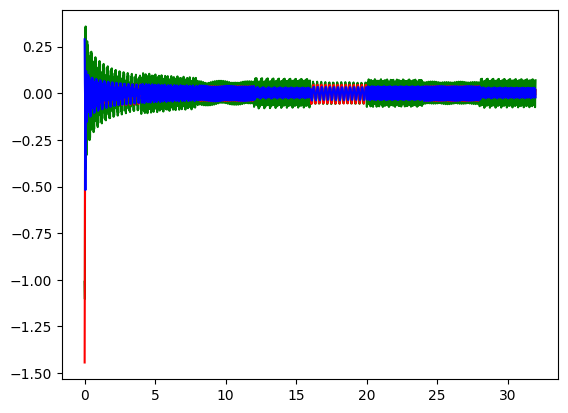

In [5]:
# estados del reservoir después de aplicarse el filtro pasa-banda.
plt.plot(t2, RS2[0, 1:], color = 'green')
plt.plot(t2, RS2[1, 1:], color = 'red')
plt.plot(t2, RS2[2, 1:], color = 'blue')
plt.show()

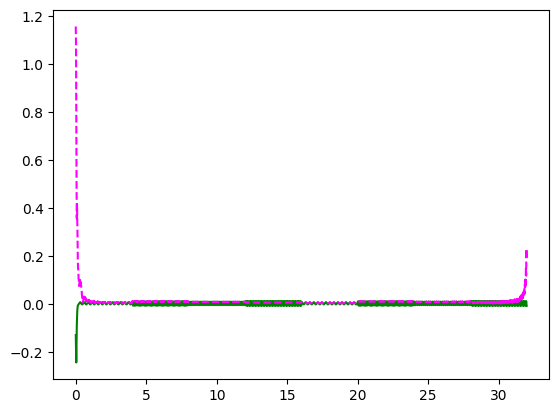

In [5]:
plt.plot(t2, RS2[0, 1:], color = 'green')
plt.plot(t2, amplitude_envelope2[0, 1:], linestyle="dashed", color = 'magenta')
plt.show()

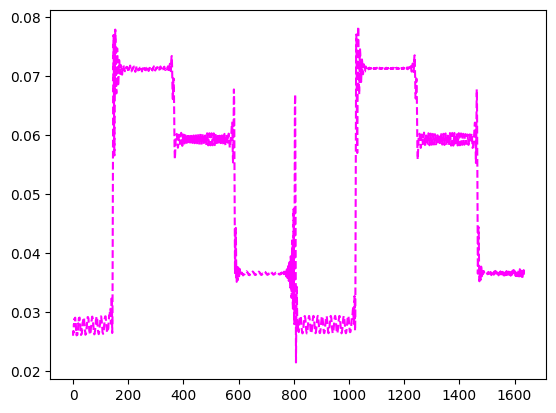

In [6]:
# Eliminamos los primeros y ultimos puntos para estabilizar el reservorio
stable_start = min(75, amplitude_envelope2.shape[1])
input_sequence2 = amplitude_envelope2[:, stable_start:-50]
plt.plot(input_sequence2[0, 1:], linestyle="dashed", color = 'magenta')
plt.show()

In [7]:
# Agrupamiento con algoritmo GMM(Gaussian Mixture Model).

def clustering_gmm(input_sequence, n_components=4):  
    """  
    Función para realizar agrupamiento usando GMM.  

    Args:  
    - input_sequence: Array de entrada procesado para el agrupamiento.  
    - num_clusters: Número de estados cerebrales. Default es 4.  

    Returns:  
    - labels: Etiquetas de los clústeres asignados a cada muestra de entrada. 
    """
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    cluster_labels = gmm.fit_predict(input_sequence.T)
    return cluster_labels

idx_gmm = clustering_gmm(input_sequence2)

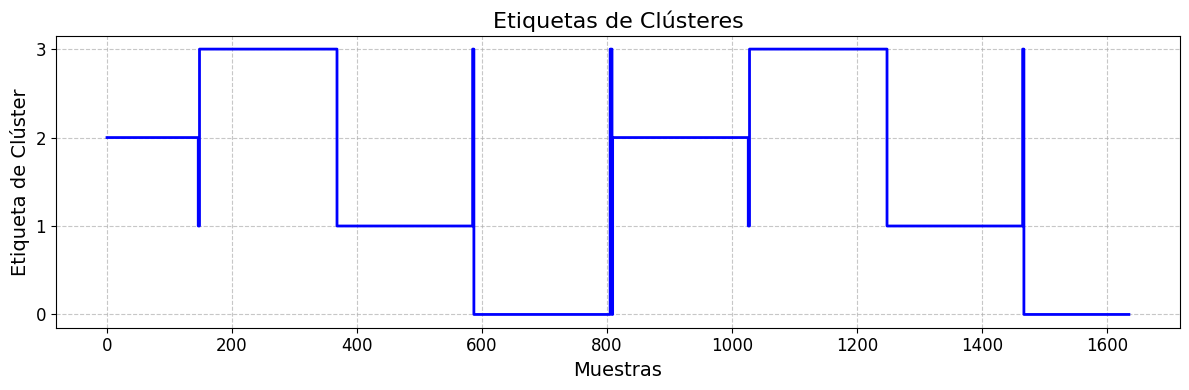

In [25]:
plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence2.shape[1]), idx_gmm, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(4))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xlim(100, 200)  
plt.tight_layout() 
plt.show()

Graficamos la señal junto con el clustering realizado.

In [26]:
stable_start = min(75, len(secuencia2))
secuencia22 = secuencia2[stable_start:-50]
secuencia22.shape

(1635,)

In [20]:
stable_start = min(75, len(t2))
t22 = t2[stable_start:-50]
t22.shape

(1635,)

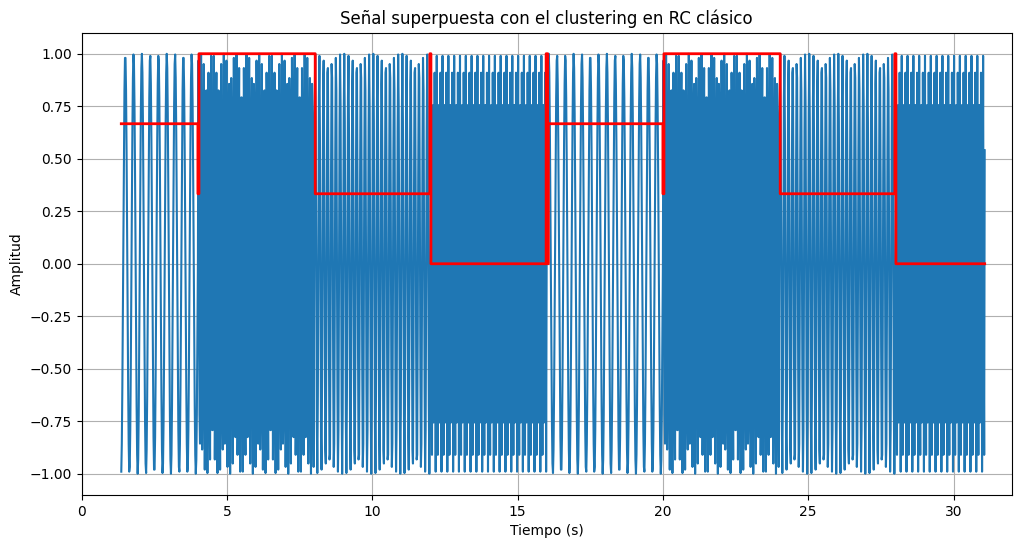

In [29]:
plt.figure(figsize=(12, 6))  
plt.plot(t22, secuencia22)
plt.step(t22, idx_gmm[1:]/3, where='post', color='red', linewidth=2) 
plt.title('Señal superpuesta con el clustering en RC clásico')  
plt.xlabel('Tiempo (s)')  
plt.ylabel('Amplitud')  
plt.xlim(0, t_total)  
plt.grid()  
plt.show()

## Implementación cuántica.

In [8]:
# Número de qubits (tamaño del reservoir cuántico)
num_qubits = 3
# Profundidad del reservoir.
num_layers = 1  

# Creamos un dispositivo cuántico
dev3 = qml.device("default.qubit", wires=num_qubits)

In [9]:
# Definir el Quantum Reservoir  
def quantum_reservoir(reservoir_weights, connectivity):  
    """Quantum Reservoir con compuertas CNOT y rotaciones."""    
    for i in range(num_qubits):
         for j in range(num_qubits):
            # Rotación aleatoria en cada qubit  
            qml.RX(reservoir_weights[i,j], wires= i)
            
    # Aplicar entrelazamiento entre los qubits seleccionados.(conectividad limitada)
    if connectivity == 'ring':
        for j in range(num_qubits - 1):
            qml.CNOT(wires=[j, j+1])  # Apply entanglement between adjacent qubits
                     
                
    if connectivity == 'star':
    # Entangling the first qubit (central node) with all other qubits
        central_qubit = 0  # We use qubit 0 as the central node
        for j in range(1, num_qubits):
             qml.CNOT(wires=[central_qubit, j])
 
    if connectivity == 'random':
            # Crear pares de qubits aleatorios
              qubit_pairs = [(j, k) for j in range(num_qubits) for k in range(j + 1, num_qubits)]
              random.shuffle(qubit_pairs)
            # Entrelazar aleatoriamente
              for j, k in qubit_pairs[:num_qubits // 2]:
                  qml.CNOT(wires=[j, k])
 
    elif connectivity == 'full':
            # Full connectivity: entangle all pairs of qubits
              for j in range(num_qubits):
                 for k in range(j + 1, num_qubits):  # Loop over all pairs of qubits
                    qml.CNOT(wires=[j, k])  # Apply entanglement between qubit j and k

In [10]:
# Define Quantum Node
@qml.qnode(dev3)
def quantum_echo_state_network(input_data, prev_output, weights_in, weights_rc, reservoir_weights, connectivity):
    """Quantum Echo State Network (QESN)"""
    # Encode input and previous output into qubits
    for i in range(num_qubits):
        qml.RX(.05*weights_in[i] * input_data + .95*weights_rc[i] * prev_output[i], wires=i)
    
    # Evolve through the quantum reservoir
    quantum_reservoir(reservoir_weights, connectivity=connectivity)
    
    # Devolvemos un vector de probabilidades de los estados.
    return qml.probs(wires=range(num_qubits))

In [13]:
# Initialize parameters
weights_in = np.random.uniform(-np.pi, np.pi, num_qubits)
weights_rc = np.random.uniform(-np.pi, np.pi, num_qubits)
reservoir_weights = np.random.uniform(-np.pi, np.pi, (num_qubits, num_qubits))

sec2 = secuencia2.reshape(1, len(secuencia2))
input_series2 = sec2
time_steps = input_series2.shape[1]

# Run QESN
outputs = []
prev_output = np.zeros(num_qubits)  # Initial output

for t0 in range(time_steps):
    q_prob = quantum_echo_state_network(input_series2[0, t0], prev_output, weights_in, weights_rc, reservoir_weights, connectivity='full')

    final_output = np.tanh(q_prob) # aplicamos una tangente hiperbólica al vector de probabilidades.

    # Almacenamos el resultado en la lista.
    outputs.append(final_output)
    prev_output = final_output  # Recurrent connection
    print(f"Step {t0}: {final_output}")

# Convertimos outputs a numpy array.
outputs = np.array(outputs)

Step 0: [0.39367843 0.18385706 0.01950773 0.04362992 0.00981555 0.02196126
 0.20636237 0.09329301]
Step 1: [0.13396437 0.05770185 0.01860025 0.04337422 0.05442492 0.12642488
 0.37540415 0.16757725]
Step 2: [0.30156915 0.13999824 0.02671785 0.05895475 0.02295276 0.05065907
 0.26117358 0.12046932]
Step 3: [0.18835611 0.0853109  0.0259858  0.05787397 0.04615823 0.10260343
 0.32638968 0.15082024]
Step 4: [0.26280426 0.12183254 0.02913529 0.0639685  0.03096625 0.06797895
 0.27848704 0.12941037]
Step 5: [0.21444716 0.09588095 0.02666544 0.06033503 0.03980624 0.08996028
 0.31426381 0.142635  ]
Step 6: [0.24949758 0.10954285 0.02512912 0.0581806  0.03092903 0.07157508
 0.30383363 0.1345626 ]
Step 7: [0.22873002 0.09581903 0.02130469 0.0515755  0.03170045 0.0766736
 0.33329712 0.14207198]
Step 8: [0.24614419 0.09923964 0.0182191  0.04595699 0.02567087 0.06471594
 0.34003169 0.1393931 ]
Step 9: [0.2364043  0.09111827 0.01506995 0.03972402 0.0238527  0.06283252
 0.36395566 0.14363923]
Step 10: [0

(8, 1760)


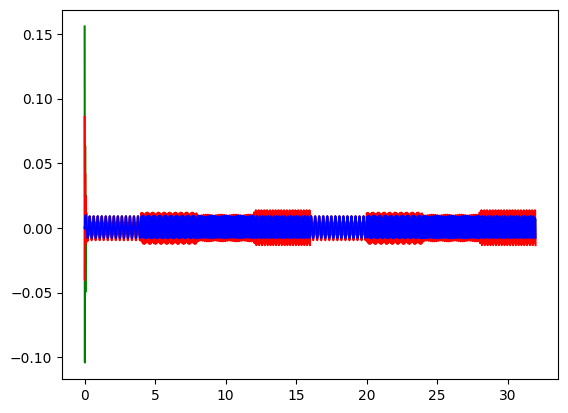

In [14]:
outputs = outputs.T

RS_cuant_2 = outputs - np.mean(outputs,axis=1, keepdims=True)
print(RS_cuant_2.shape)

plt.plot(t2, RS_cuant_2[0, :], color = 'green')
plt.plot(t2, RS_cuant_2[1, :], color = 'red')
plt.plot(t2, RS_cuant_2[2, :], color = 'blue')
plt.show()

In [15]:
# Parámetros
fs = 55  # Frecuencia de muestreo
lowcut = 3.5  # Frecuencia baja del filtro
highcut = 15  # Frecuencia alta del filtro

# Aplicar filtro antes de Hilbert
x_filtered_cuant_2 = bandpass_filter(RS_cuant_2, lowcut, highcut, fs)

In [16]:
analytic_signal = hilbert(x_filtered_cuant_2, axis = 1)
amplitude_envelope_cuant2 = np.abs(analytic_signal)
print(analytic_signal.shape)
print(amplitude_envelope_cuant2.shape)

(8, 1760)
(8, 1760)


(8, 1702)


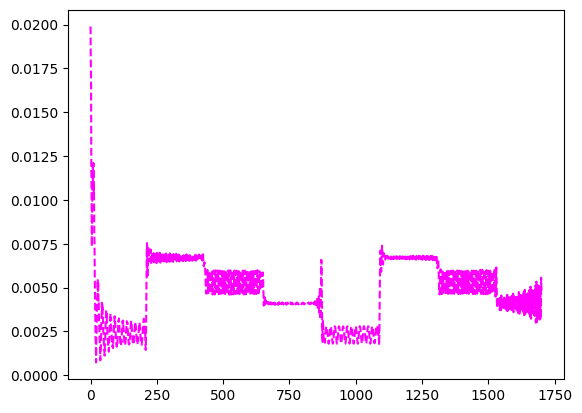

In [17]:
# Eliminar primeros puntos del reservoir.
stable_start = min(75, amplitude_envelope_cuant2.shape[0])
input_sequence_cuantico2 = amplitude_envelope_cuant2[:,stable_start:-50]
print(input_sequence_cuantico2.shape)
plt.plot(input_sequence_cuantico2[0, 1:], linestyle="dashed", color = 'magenta')
plt.show()

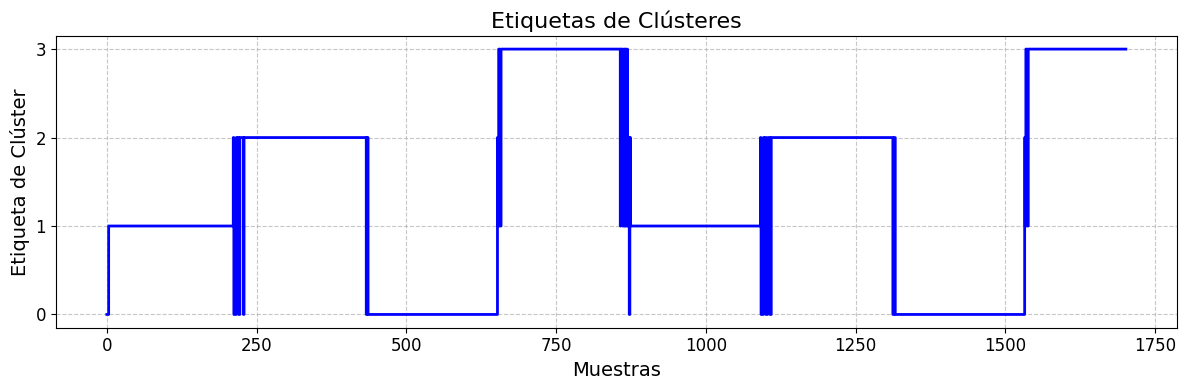

In [30]:
# CLUSTERING GMM.
idx_gmm_cuant = clustering_gmm(input_sequence_cuantico2)

plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence_cuantico2.shape[1]), idx_gmm_cuant, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(4))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xlim(100, 200)  
plt.tight_layout() 
plt.show()

Graficamos la señal junto con el clustering realizado.

In [31]:
stable_start = min(90, amplitude_envelope_cuant2.shape[0])
secuencia23 = secuencia2[stable_start:-50]

In [21]:
stable_start = min(90, amplitude_envelope_cuant2.shape[0])
t23 = t2[stable_start:-50]

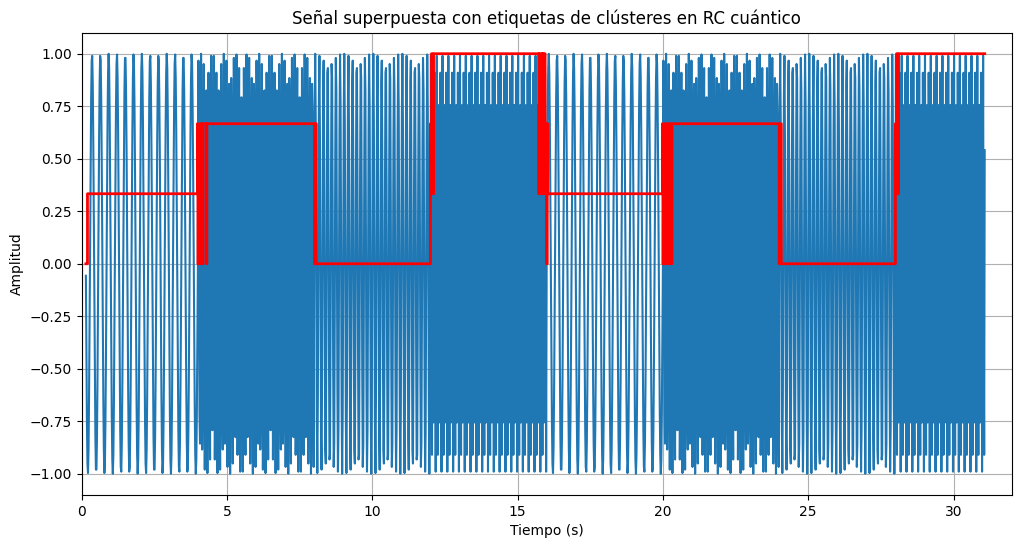

In [34]:
plt.figure(figsize=(12, 6))  
plt.plot(t23, secuencia23)
plt.step(t23, idx_gmm_cuant[:]/3, where='post', color='red', linewidth=2) 
plt.title('Señal superpuesta con etiquetas de clústeres en RC cuántico')  
plt.xlabel('Tiempo (s)')  
plt.ylabel('Amplitud')  
plt.xlim(0, t_total)  
plt.grid()  
plt.show()

# Gráficos de memoria.

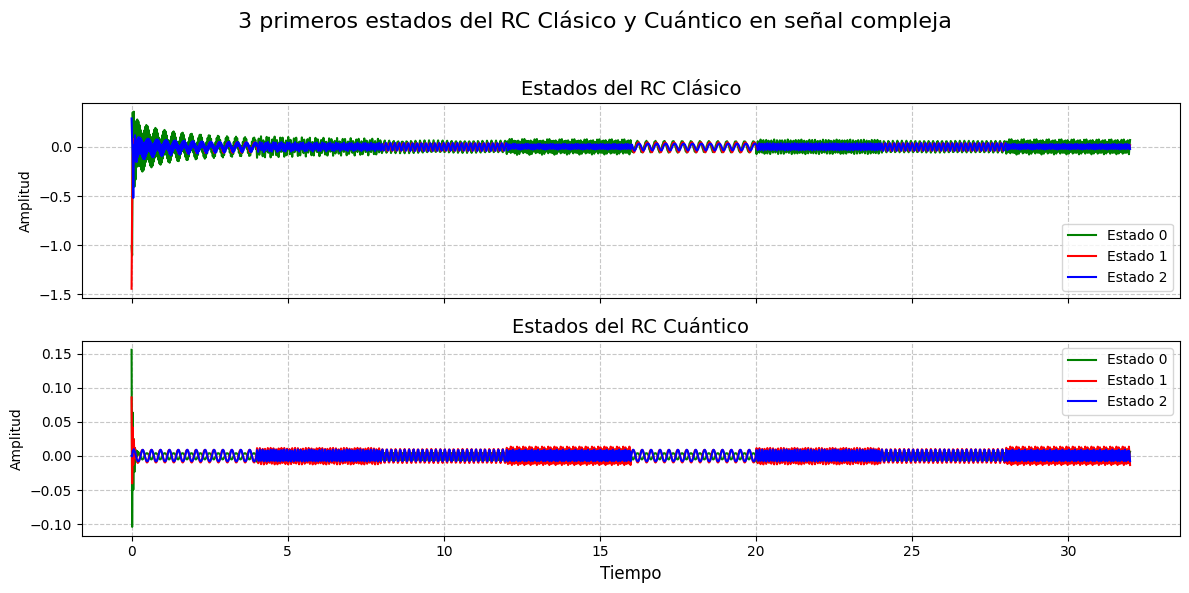

In [18]:
# Crear figura y subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Primer subplot: RC clásico
axs[0].plot(t2, RS2[0, 1:], color='green', label='Estado 0')
axs[0].plot(t2, RS2[1, 1:], color='red', label='Estado 1')
axs[0].plot(t2, RS2[2, 1:], color='blue', label='Estado 2')
axs[0].set_title('Estados del RC Clásico', fontsize=14)
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.7)

# Segundo subplot: RC cuántico
axs[1].plot(t2, RS_cuant_2[0, :], color='green', label='Estado 0')
axs[1].plot(t2, RS_cuant_2[1, :], color='red', label='Estado 1')
axs[1].plot(t2, RS_cuant_2[2, :], color='blue', label='Estado 2')
axs[1].set_title('Estados del RC Cuántico', fontsize=14)
axs[1].set_xlabel('Tiempo', fontsize=12)
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.7)

# Título global y formato
fig.suptitle('3 primeros estados del RC Clásico y Cuántico en señal compleja', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

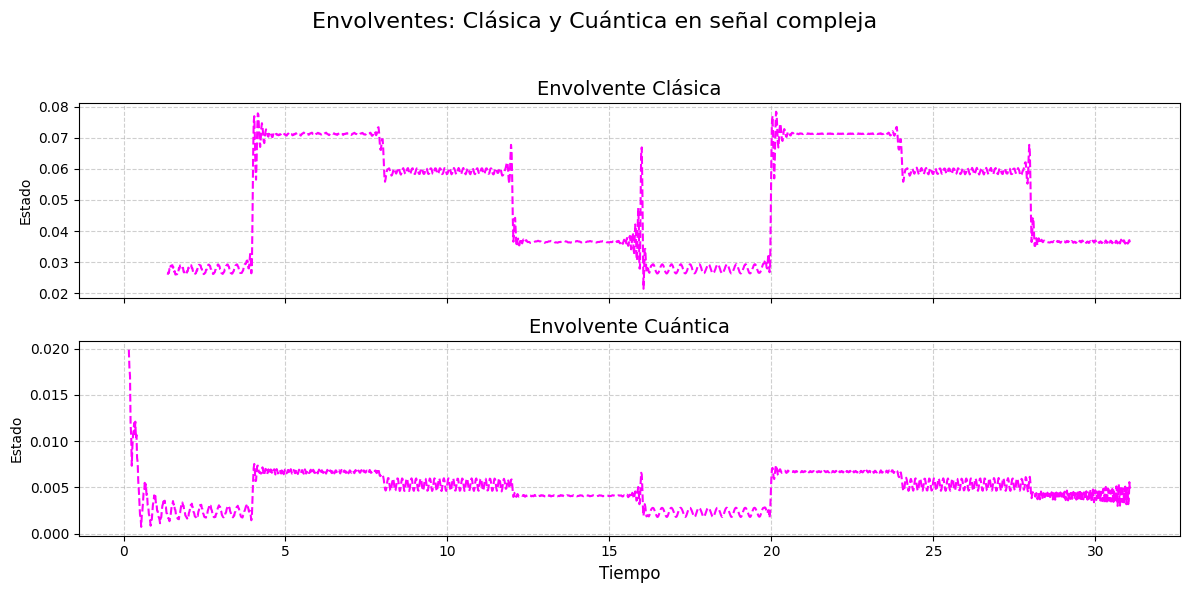

In [22]:
# Crear figura y subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Envolvente clásica
axs[0].plot(t22, input_sequence2[0, 1:], linestyle='dashed', color='magenta')
axs[0].set_title('Envolvente Clásica', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].set_ylabel("Estado")

# Envolvente cuántica
axs[1].plot(t23[1:], input_sequence_cuantico2[0, 1:], linestyle='dashed', color='magenta')
axs[1].set_title('Envolvente Cuántica', fontsize=14)
axs[1].set_xlabel('Tiempo', fontsize=12)
axs[1].set_ylabel("Estado")
axs[1].grid(True, linestyle='--', alpha=0.6)

# Título global
fig.suptitle('Envolventes: Clásica y Cuántica en señal compleja', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

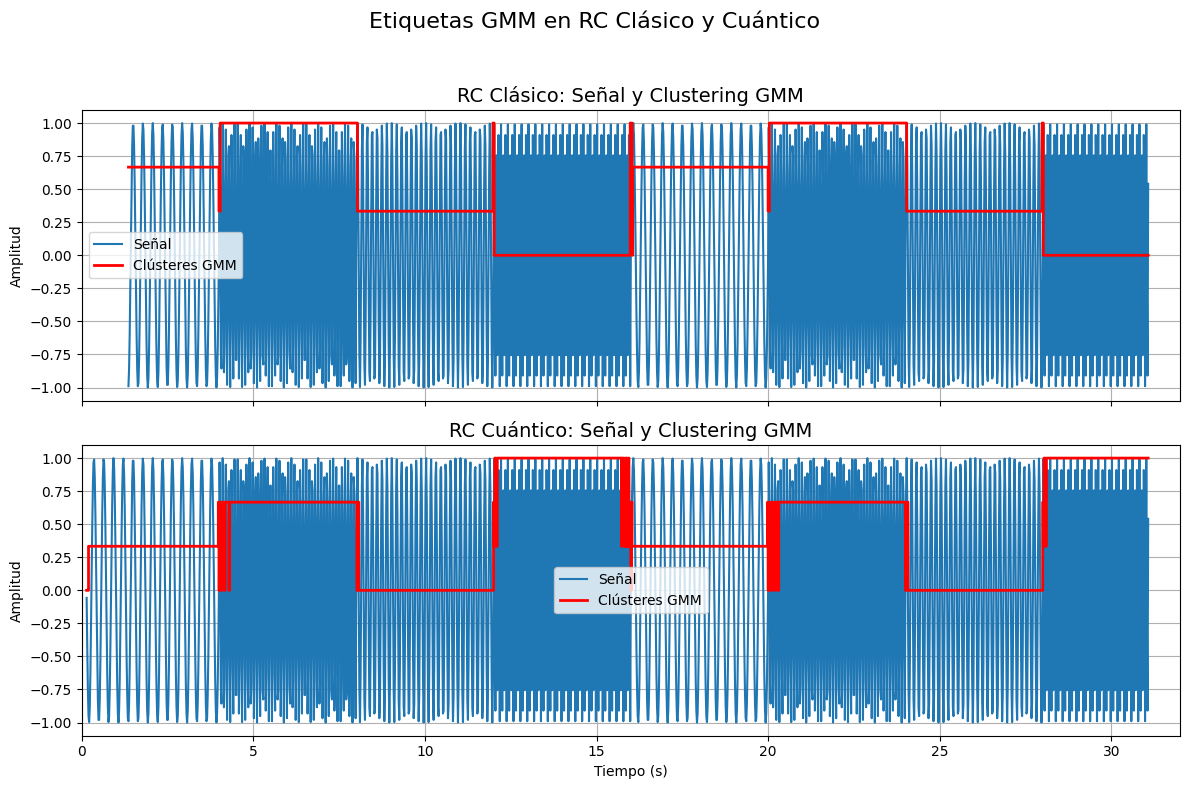

In [36]:
# Crear figura con dos subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Primer subplot: RC clásico
axs[0].plot(t22, secuencia22, label='Señal')
axs[0].step(t22, idx_gmm[1:] / 3, where='post', color='red', linewidth=2, label='Clústeres GMM')
axs[0].set_title('RC Clásico: Señal y Clustering GMM', fontsize=14)
axs[0].set_ylabel('Amplitud')
axs[0].grid(True)
axs[0].legend()

# Segundo subplot: RC cuántico
axs[1].plot(t23, secuencia23, label='Señal')
axs[1].step(t23, idx_gmm_cuant[:] / 3, where='post', color='red', linewidth=2, label='Clústeres GMM')
axs[1].set_title('RC Cuántico: Señal y Clustering GMM', fontsize=14)
axs[1].set_xlabel('Tiempo (s)')
axs[1].set_ylabel('Amplitud')
axs[1].grid(True)
axs[1].legend()

# Título global y ajuste
fig.suptitle('Etiquetas GMM en RC Clásico y Cuántico', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.xlim(0, t_total)
plt.show()

### Diferentes pruebas de conectividad.

A continuación, vamos a realizar una prueba utilizando los distintos tipos de conectividad entre los qubits para averiguar cuál funciona mejor con la señal que hemos implementado.

In [62]:
# Función que aplica el reservoir computing cuántico.

def reservoir_computing_cuantico(secuencia2, num_qubits = 3, connectivity = 'full'):  
    # Inicialización de pesos 

    weights_in = np.random.uniform(-np.pi, np.pi, num_qubits)
    weights_rc = np.random.uniform(-np.pi, np.pi, num_qubits)
    reservoir_weights = np.random.uniform(-np.pi, np.pi, (num_qubits, num_qubits))
    
    sec2 = secuencia2.reshape(1, len(secuencia2))
    input_series = sec2
    time_steps = input_series2.shape[1]
    
    # Array para almacenar las salidas  
    outputs = []  
    prev_output = np.zeros((num_qubits))  
    
    # Loop en el tiempo  
    for t in range(time_steps):  
        q_probs = quantum_echo_state_network(input_series[0, t], prev_output,   
                                             weights_in, weights_rc, reservoir_weights, connectivity = connectivity)  
        final_output = np.tanh(q_probs) # aplicamos una tangente hiperbólica al vector de probabilidades.

        # Almacenamos el resultado en la lista.
        outputs.append(final_output)
        prev_output = final_output  # Recurrent connection

    outputs = np.array(outputs)
    # Transponer y ajustar el array de salida  
    outputs_tr = outputs.T  
    # Restar la media por fila  
    outputs_adj = outputs_tr - np.mean(outputs_tr, axis=1, keepdims=True)
    # filtro pasa-banda
    outputs_adj_filt = bandpass_filter(outputs_adj, lowcut=3.5, highcut=15, fs=55)  
    
    # Aplicar transformada de Hilbert para obtener la señal analítica  
    analytic_signal = hilbert(outputs_adj_filt, axis=1)  
    amplitude_envelope = np.abs(analytic_signal)  
    # Eliminar primeros puntos del reservoir.
    stable_start = min(90, amplitude_envelope.shape[0])
    input_sequence_cuantico = amplitude_envelope[:,stable_start:-50]
    
    return input_sequence_cuantico

In [67]:
# Código que aplica las distintas conectividades entre los qubits.
conectividades = ['full','ring','star','random']
# lista para almacenar el clustering realizado con cada conectividad.
clustering_conect = []

for i in range(len(conectividades)):
    input_sequence = reservoir_computing_cuantico(secuencia2, connectivity=conectividades[i])
    idx_gmm = clustering_gmm(input_sequence)
    clustering_conect.append(idx_gmm)

print(len(clustering_conect))

4


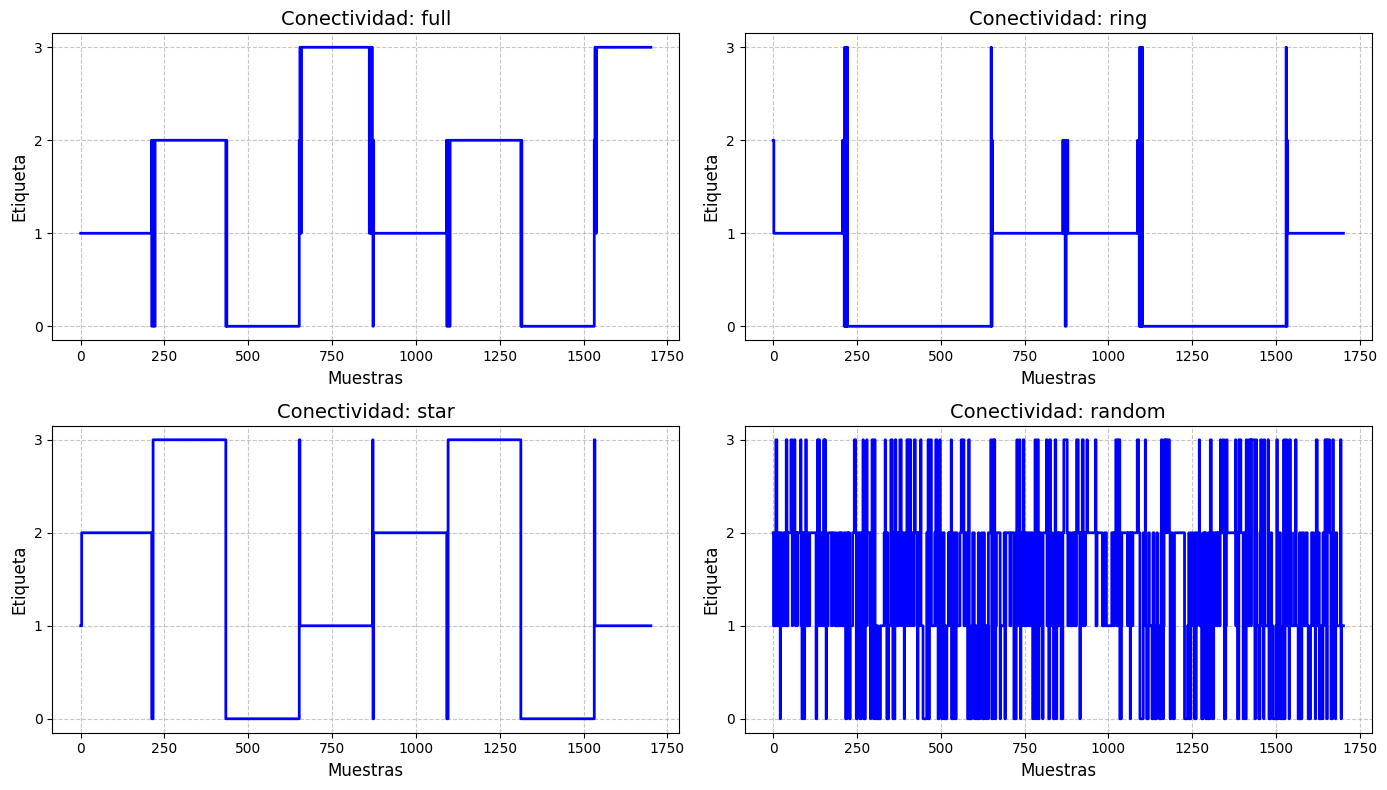

In [68]:
# Representación gráfica de los distintos clustering.
plt.figure(figsize=(14, 8))

for i in range(len(clustering_conect)):
    idx = clustering_conect[i]
    
    plt.subplot(2, 2, i+1)  # 2 filas, 2 columnas de subplots
    plt.step(range(len(idx)), idx, where='post', color='blue', linewidth=2)
    plt.title(f'Conectividad: {conectividades[i]}', fontsize=14)
    plt.xlabel('Muestras', fontsize=12)
    plt.ylabel('Etiqueta', fontsize=12)
    plt.yticks(np.arange(4))  # 4 clusters
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Observamos que la conectividad 'full' y 'star' funcionan bien ya que ambas detectan los cambios en la frecuencia de la señal, por lo que estas conectividades son las que vamos a considerar a partir de ahora.